加载 Olivetti 人脸数据集...
训练集大小: (320, 4096), 测试集大小: (80, 4096)
已向数据添加椒盐噪声 (污染比例 = 20%)
PCA 保留 135 个主成分 (解释方差 60%)

开始 RPCA 分解训练集 (含椒盐噪声)...
RPCA 收敛于迭代 48
RPCA 训练集分解完成，用时 10.95 秒

开始 RPCA 分解测试集 (含椒盐噪声)...
RPCA 测试集分解完成

--- 分类结果 (KNN, k=1) ---
含椒盐噪声的原始特征准确率: 0.8250
PCA 特征准确率: 0.4750
RPCA 低秩特征准确率: 0.8625


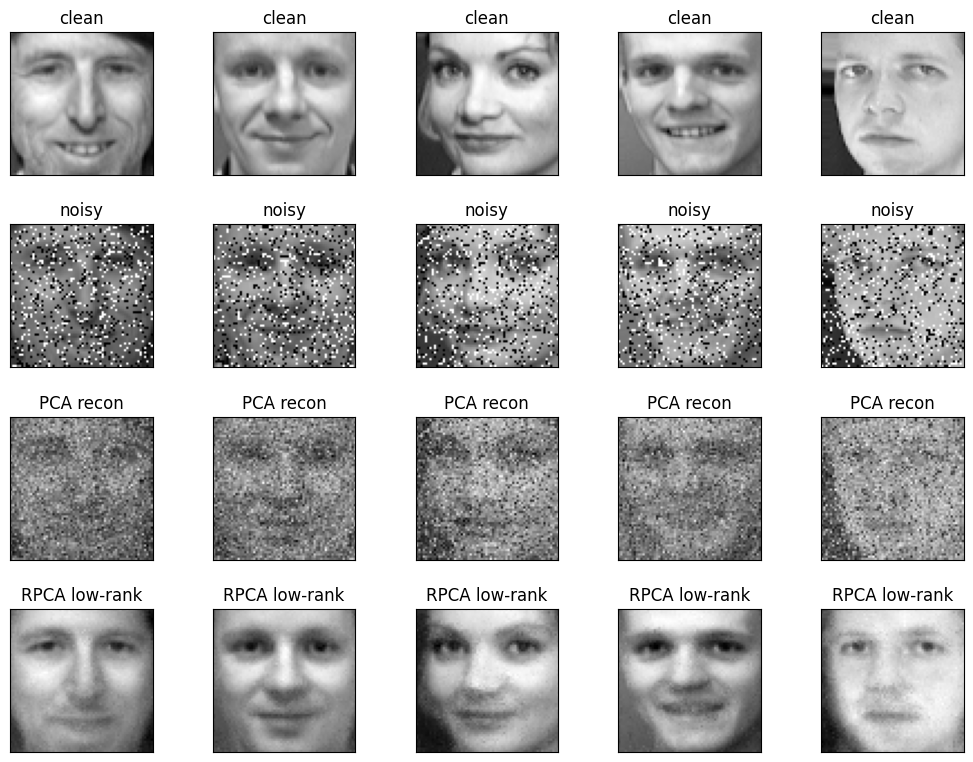

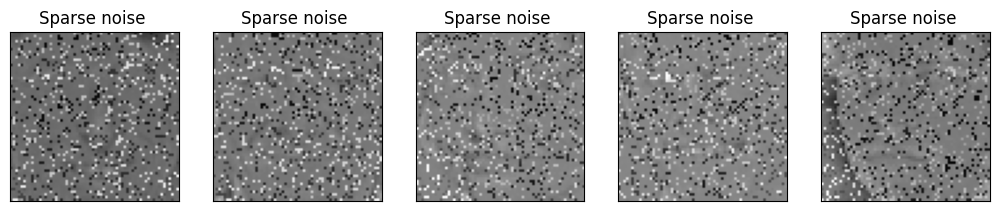

In [ ]:
#（学生在此实验期间一直准备一个十分重要的比赛，所以成品效果可能不高，还请老师谅解）
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
import time

# ------------------------------
# 1. 加载数据
# ------------------------------
print("加载 Olivetti 人脸数据集...")
faces = fetch_olivetti_faces(shuffle=True, random_state=42)
X = faces.data      # (400, 4096) 每张图 64x64，像素值范围 [0,1]
y = faces.target    # (400,) 标签 0~39

# 划分训练集和测试集 (80% 训练, 20% 测试，保持类别分布)
X_train_clean, X_test_clean, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ------------------------------
# 2. 添加椒盐噪声
# ------------------------------
def add_salt_pepper_noise(X, noise_ratio=0.20):
    X_noisy = X.copy()
    n_samples, n_features = X.shape
    # 每个样本独立添加噪声
    for i in range(n_samples):
        # 随机选择要污染的像素索引
        n_noisy = int(n_features * noise_ratio)
        indices = np.random.choice(n_features, n_noisy, replace=False)
        # 椒盐各占一半
        n_salt = n_noisy // 2
        n_pepper = n_noisy - n_salt
        salt_idx = indices[:n_salt]
        pepper_idx = indices[n_salt:n_noisy]
        # 盐噪声（白点）设为 1.0，胡椒噪声（黑点）设为 0.0
        X_noisy[i, salt_idx] = 1.0
        X_noisy[i, pepper_idx] = 0.0
    return X_noisy

noise_ratio = 0.2   # 10% 的像素被污染（5% 盐 + 5% 胡椒）
X_train = add_salt_pepper_noise(X_train_clean, noise_ratio=noise_ratio)
X_test  = add_salt_pepper_noise(X_test_clean,  noise_ratio=noise_ratio)

print(f"训练集大小: {X_train.shape}, 测试集大小: {X_test.shape}")
print(f"已向数据添加椒盐噪声 (污染比例 = {noise_ratio*100:.0f}%)")

# ------------------------------
# 3. PCA 实现
# ------------------------------
class PCA:
    """主成分分析 (PCA) 使用协方差矩阵的特征值分解"""
    def __init__(self, n_components):
        self.n_components = n_components
        self.components_ = None
        self.mean_ = None
        self.explained_variance_ = None
        self.total_variance_ = None

    def fit(self, X):
        self.mean_ = np.mean(X, axis=0)
        X_centered = X - self.mean_
        n_samples = X_centered.shape[0]
        cov_matrix = X_centered.T @ X_centered / (n_samples - 1)
        eigvals, eigvecs = np.linalg.eigh(cov_matrix)
        idx = np.argsort(eigvals)[::-1]
        eigvals = eigvals[idx]
        eigvecs = eigvecs[:, idx]
        self.components_ = eigvecs[:, :self.n_components].T
        self.explained_variance_ = eigvals[:self.n_components]
        self.total_variance_ = np.sum(eigvals)
        return self

    def transform(self, X):
        X_centered = X - self.mean_
        return X_centered @ self.components_.T

    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

# ------------------------------
# 4. RPCA 实现 (ADMM)
# ------------------------------
class RPCA:

    def __init__(self, lambda_=None, max_iter=800, tol=1e-7, verbose=False):
        self.lambda_ = lambda_
        self.max_iter = max_iter
        self.tol = tol
        self.verbose = verbose

    def fit(self, X):
        if self.lambda_ is None:
            m, n = X.shape
            self.lambda_ = 1.0 / np.sqrt(max(m, n))

        L = np.zeros_like(X)
        S = np.zeros_like(X)
        Y = np.zeros_like(X)
        mu = 1e-3
        mu_max = 1e10
        rho = 1.5

        for i in range(self.max_iter):
            M = X - S + Y / mu
            U, Sigma, Vt = np.linalg.svd(M, full_matrices=False)
            thresh = 1.0 / mu
            Sigma_th = np.maximum(Sigma - thresh, 0)
            L_new = U @ np.diag(Sigma_th) @ Vt

            N = X - L_new + Y / mu
            thresh_s = self.lambda_ / mu
            S_new = np.sign(N) * np.maximum(np.abs(N) - thresh_s, 0)

            Y = Y + mu * (X - L_new - S_new)
            mu = min(mu * rho, mu_max)

            primal_res = np.linalg.norm(X - L_new - S_new, 'fro')
            dual_res = np.linalg.norm(L_new - L, 'fro') + np.linalg.norm(S_new - S, 'fro')
            if primal_res < self.tol and dual_res < self.tol:
                if self.verbose:
                    print(f"RPCA 收敛于迭代 {i+1}")
                break

            L, S = L_new, S_new

        self.L_ = L
        self.S_ = S
        return self

# ------------------------------
# 5. 确定 PCA 主成分数 
# ------------------------------
def determine_n_components(X, variance_ratio=0.60):
    pca_temp = PCA(n_components=min(X.shape[1], X.shape[0]))
    pca_temp.fit(X)
    cumsum = np.cumsum(pca_temp.explained_variance_ / pca_temp.total_variance_)
    n = np.argmax(cumsum >= variance_ratio) + 1
    return n

n_components_pca = determine_n_components(X_train, variance_ratio=0.60)
print(f"PCA 保留 {n_components_pca} 个主成分 (解释方差 60%)")

# 训练 PCA
pca = PCA(n_components=n_components_pca)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# ------------------------------
# 6. RPCA 分解 (基于噪声数据)
# ------------------------------
print("\n开始 RPCA 分解训练集 (含椒盐噪声)...")
start = time.time()
rpca = RPCA(max_iter=800, tol=1e-5, verbose=True)
rpca.fit(X_train.T)               # X_train.T 形状 (4096, 320)
L_train = rpca.L_.T               # 转置为 (320, 4096)，每行一个样本
print(f"RPCA 训练集分解完成，用时 {time.time()-start:.2f} 秒")

print("\n开始 RPCA 分解测试集 (含椒盐噪声)...")
X_test_T = X_test.T               # (4096, 80)
rpca_test = RPCA(lambda_=rpca.lambda_, max_iter=800, tol=1e-5)
rpca_test.fit(X_test_T)
L_test = rpca_test.L_.T           # (80, 4096)
print(f"RPCA 测试集分解完成")

# ------------------------------
# 7. 分类比较 (KNN, k=5)
# ------------------------------
knn = KNeighborsClassifier(n_neighbors=1)

print("\n--- 分类结果 (KNN, k=1) ---")
# 原始特征 (含椒盐噪声)
knn.fit(X_train, y_train)
y_pred_raw = knn.predict(X_test)
acc_raw = accuracy_score(y_test, y_pred_raw)
print(f"含椒盐噪声的原始特征准确率: {acc_raw:.4f}")

# PCA 特征 (基于噪声)
knn.fit(X_train_pca, y_train)
y_pred_pca = knn.predict(X_test_pca)
acc_pca = accuracy_score(y_test, y_pred_pca)
print(f"PCA 特征准确率: {acc_pca:.4f}")

# RPCA 低秩特征 (基于噪声)
knn.fit(L_train, y_train)
y_pred_rpca = knn.predict(L_test)
acc_rpca = accuracy_score(y_test, y_pred_rpca)
print(f"RPCA 低秩特征准确率: {acc_rpca:.4f}")

# ------------------------------
# 8. 可视化对比
# ------------------------------
def plot_gallery(images, titles, h, w, n_row=2, n_col=5):
    plt.figure(figsize=(2*n_col, 2*n_row))
    plt.subplots_adjust(bottom=0, left=0.01, right=0.99, top=0.90, hspace=0.35)
    for i in range(n_row * n_col):
        plt.subplot(n_row, n_col, i+1)
        plt.imshow(images[i].reshape(h, w), cmap=plt.cm.gray)
        plt.title(titles[i], size=12)
        plt.xticks(())
        plt.yticks(())
    plt.show()

# 随机选取几个训练样本
n_samples = 5
idx = np.random.choice(X_train.shape[0], n_samples, replace=False)
sample_noisy = X_train[idx]           # 椒盐噪声图像
sample_clean = X_train_clean[idx]     # 对应的干净图像

# PCA 重建
pca_reconstructed = pca.transform(sample_noisy) @ pca.components_ + pca.mean_

# RPCA 低秩部分
rpca_lowrank = L_train[idx]

h, w = 64, 64
all_images = np.vstack([sample_clean, sample_noisy, pca_reconstructed, rpca_lowrank])
all_titles = (['clean'] * n_samples + ['noisy'] * n_samples +
              ['PCA recon'] * n_samples + ['RPCA low-rank'] * n_samples)
plot_gallery(all_images, all_titles, h, w, n_row=4, n_col=n_samples)

# 显示 RPCA 分解出的稀疏部分（即分离出的椒盐噪声）
sparse_images = rpca.S_.T[idx]   # S_ 形状 (4096,320)，转置后 (320,4096)
titles_sparse = ['Sparse noise '] * n_samples
plot_gallery(sparse_images, titles_sparse, h, w, n_row=1, n_col=n_samples)

加载 Olivetti 人脸数据集...
训练集大小: (320, 4096), 测试集大小: (80, 4096)
添加椒盐噪声，污染比例 = 20%

训练 PCANet（椒盐噪声图像）...
训练 PCANet 第一层...
生成第一层特征图...
训练 PCANet 第二层...
提取 PCANet 特征...

训练修正后的可学习 LRPCA（使用干净数据作为监督）...
使用设备: cpu
Epoch  10, Loss: 0.004288, eta=0.7835, zeta_decay=0.9000
Epoch  20, Loss: 0.004274, eta=0.7661, zeta_decay=0.9000
Epoch  30, Loss: 0.004261, eta=0.7481, zeta_decay=0.9000
Epoch  40, Loss: 0.004249, eta=0.7296, zeta_decay=0.9000
Epoch  50, Loss: 0.004238, eta=0.7110, zeta_decay=0.9000
LRPCA迭代2次收敛，相对误差=0.229439

--- 分类结果 (KNN, k=1) 在椒盐噪声测试集上 ---
PCANet 特征准确率: 0.4000
修正后 LRPCA 特征准确率: 0.7875


C:\Users\81349\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20462 (\N{CJK UNIFIED IDEOGRAPH-4FEE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\81349\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAPH-6B63}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\81349\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21518 (\N{CJK UNIFIED IDEOGRAPH-540E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


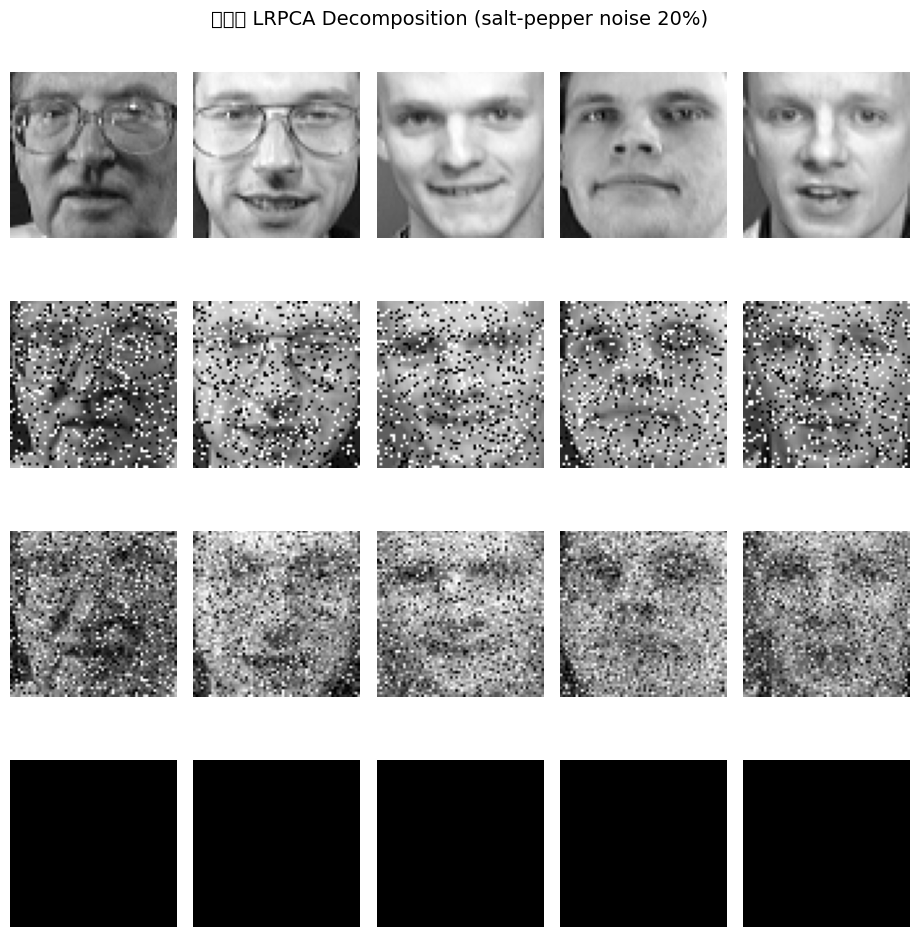


显示 PCANet 第一层 PCA 滤波器...


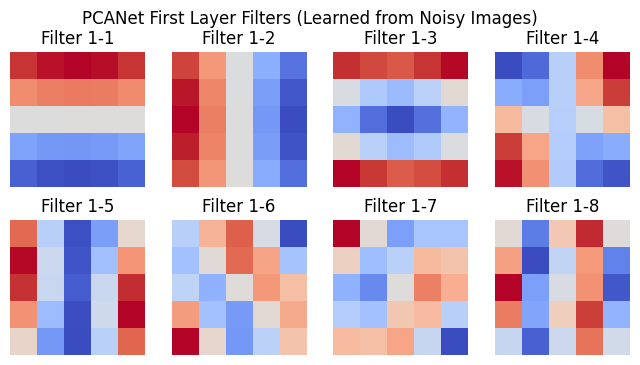


显示 PCANet 第二层 PCA 滤波器...


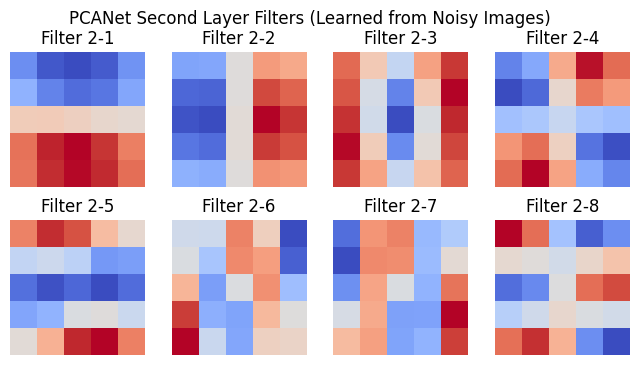

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from scipy.ndimage import convolve
import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn import functional as F

# ------------------------------
# 1. 加载数据并添加椒盐噪声（保持不变）
# ------------------------------
print("加载 Olivetti 人脸数据集...")
faces = fetch_olivetti_faces(shuffle=True)
X = faces.data      # (400, 4096) 每张图 64x64
y = faces.target

# 归一化到 [0,1]（原始数据已经在该范围，但确保统一）
X = X / 255.0 if X.max() > 1 else X

# 划分训练集和测试集
X_train_clean, X_test_clean, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y,
)

# ------------------------------
# 添加椒盐噪声函数（保持不变）
# ------------------------------
def add_salt_pepper_noise(X, noise_ratio=0.20):
    X_noisy = X.copy()
    n_samples, n_features = X.shape
    for i in range(n_samples):
        n_noisy = int(n_features * noise_ratio)
        indices = np.random.choice(n_features, n_noisy, replace=False)
        n_salt = n_noisy // 2
        n_pepper = n_noisy - n_salt
        salt_idx = indices[:n_salt]
        pepper_idx = indices[n_salt:n_noisy]
        X_noisy[i, salt_idx] = 1.0   # 盐噪声（白点）
        X_noisy[i, pepper_idx] = 0.0 # 胡椒噪声（黑点）
    return X_noisy

noise_ratio = 0.20   # 20% 像素被污染
X_train_noisy = add_salt_pepper_noise(X_train_clean, noise_ratio)
X_test_noisy = add_salt_pepper_noise(X_test_clean, noise_ratio)

# 图像版本（用于 PCANet 和可视化）
h, w = 64, 64
X_train_img = X_train_clean.reshape(-1, h, w)
X_test_img = X_test_clean.reshape(-1, h, w)
X_train_img_noisy = X_train_noisy.reshape(-1, h, w)
X_test_img_noisy = X_test_noisy.reshape(-1, h, w)

print(f"训练集大小: {X_train_noisy.shape}, 测试集大小: {X_test_noisy.shape}")
print(f"添加椒盐噪声，污染比例 = {noise_ratio*100:.0f}%")

# ------------------------------
# 2. PCANet 定义（保持不变）
# ------------------------------
class PCANet:
    def __init__(self, k1=5, k2=5, L1=8, L2=8, block_size=(8,6), overlap_ratio=0.5):
        self.k1 = k1
        self.k2 = k2
        self.L1 = L1
        self.L2 = L2
        self.block_size = block_size
        self.overlap_ratio = overlap_ratio
        self.filters1 = None
        self.filters2 = None

    def _extract_patches(self, images, k1, k2):
        n_images = len(images)
        h, w = images[0].shape
        patch_rows = h - k1 + 1
        patch_cols = w - k2 + 1
        patches = []
        for img in images:
            for i in range(patch_rows):
                for j in range(patch_cols):
                    patch = img[i:i+k1, j:j+k2].flatten()
                    patches.append(patch)
        patches = np.array(patches)
        mean_patch = np.mean(patches, axis=1, keepdims=True)
        patches_centered = patches - mean_patch
        return patches_centered.T

    def fit(self, images):
        print("训练 PCANet 第一层...")
        X = self._extract_patches(images, self.k1, self.k2)
        cov = X @ X.T
        eigvals, eigvecs = np.linalg.eigh(cov)
        idx = np.argsort(eigvals)[::-1]
        eigvecs = eigvecs[:, idx]
        self.filters1 = []
        for l in range(self.L1):
            filt = eigvecs[:, l].reshape(self.k1, self.k2)
            self.filters1.append(filt)

        print("生成第一层特征图...")
        stage1_maps = []
        for img in images:
            img_maps = []
            for filt in self.filters1:
                conv = convolve(img, filt, mode='constant', cval=0.0)
                img_maps.append(conv)
            stage1_maps.append(img_maps)

        print("训练 PCANet 第二层...")
        all_patches = []
        for img_maps in stage1_maps:
            for fmap in img_maps:
                patches = self._extract_patches([fmap], self.k1, self.k2)
                all_patches.append(patches)
        Y = np.hstack(all_patches)
        cov2 = Y @ Y.T
        eigvals2, eigvecs2 = np.linalg.eigh(cov2)
        idx2 = np.argsort(eigvals2)[::-1]
        eigvecs2 = eigvecs2[:, idx2]
        self.filters2 = []
        for l in range(self.L2):
            filt = eigvecs2[:, l].reshape(self.k1, self.k2)
            self.filters2.append(filt)
        self.stage1_maps = stage1_maps

    def transform(self, images):
        stage1_maps = []
        for img in images:
            img_maps = []
            for filt in self.filters1:
                conv = convolve(img, filt, mode='constant', cval=0.0)
                img_maps.append(conv)
            stage1_maps.append(img_maps)

        stage2_maps = []
        for img_maps in stage1_maps:
            img_stage2 = []
            for fmap in img_maps:
                for filt in self.filters2:
                    conv = convolve(fmap, filt, mode='constant', cval=0.0)
                    img_stage2.append(conv)
            stage2_maps.append(img_stage2)

        features = []
        for img_stage2 in stage2_maps:
            int_maps = []
            for i in range(0, len(img_stage2), self.L2):
                group = img_stage2[i:i+self.L2]
                bin_maps = [(g > 0).astype(np.uint8) for g in group]
                int_map = np.zeros_like(bin_maps[0], dtype=np.uint8)
                for bit, bmap in enumerate(bin_maps):
                    int_map += (bmap << bit)
                int_maps.append(int_map)

            feat = []
            h, w = int_maps[0].shape
            block_h, block_w = self.block_size
            stride_h = int(block_h * (1 - self.overlap_ratio))
            stride_w = int(block_w * (1 - self.overlap_ratio))
            for int_map in int_maps:
                for i in range(0, h - block_h + 1, stride_h):
                    for j in range(0, w - block_w + 1, stride_w):
                        block = int_map[i:i+block_h, j:j+block_w]
                        hist, _ = np.histogram(block, bins=2**self.L2, range=(0, 2**self.L2-1))
                        feat.extend(hist)
            features.append(feat)
        return np.array(features)

# ------------------------------
# 3. 修正后的可学习 LRPCA (PyTorch 版)
# ------------------------------
class LRPCA_Learnable(nn.Module):
    def __init__(self, r, max_iter=25, init_eta=0.8, init_zeta_decay=0.9, 
                 zeta_min=1e-6, tol=1e-6, weight_decay=1e-4):
        super(LRPCA_Learnable, self).__init__()
        self.r = r                  # 低秩矩阵的秩
        self.max_iter = max_iter    # 最大迭代次数
        self.tol = tol              # 收敛阈值（早停）
        self.zeta_min = zeta_min    # zeta衰减下限
        self.weight_decay = weight_decay  # 权重衰减（正则化）
        
        # 可学习参数 + 约束（使用sigmoid将参数映射到合理范围）
        self.eta_logit = nn.Parameter(torch.tensor(np.log(init_eta/(1-init_eta)), dtype=torch.float32))  # eta ∈ (0,1)
        self.zeta_decay_logit = nn.Parameter(torch.tensor(np.log(init_zeta_decay/(1-init_zeta_decay)), dtype=torch.float32))  # zeta_decay ∈ (0,1)

    @property
    def eta(self):
        # 将logit映射到 (0,1) 区间，保证学习率为正且合理
        return torch.sigmoid(self.eta_logit)
    
    @property
    def zeta_decay(self):
        # 将logit映射到 (0,1) 区间，保证衰减系数合理
        return torch.sigmoid(self.zeta_decay_logit)

    def forward(self, Y):
        """
        Y: 输入噪声数据，shape=(n_samples, n_features)
        返回: L_recon (低秩重建, shape同Y), S_recon (稀疏噪声, shape同Y)
        """
        Y_T = Y.T  # (n_features, n_samples) = (4096, 320)
        m, n = Y_T.shape
        r = self.r
        device = Y_T.device
        eye_r = torch.eye(r, device=device)  # 预定义r阶单位矩阵，避免重复创建
        
        # 初始化S0（稀疏噪声）- 数值稳定版
        zeta0 = torch.max(torch.abs(Y_T)) + 1e-8  # 避免0值
        S = torch.where(torch.abs(Y_T) > zeta0,
                        Y_T - torch.sign(Y_T) * zeta0,
                        torch.zeros_like(Y_T))
        
        # 初始化L0, R0（低秩矩阵分解）- 增加数值稳定性
        M = Y_T - S
        # SVD分解 + 数值保护（避免0奇异值）
        U, Sigma, Vt = torch.linalg.svd(M, full_matrices=False)
        Sigma = torch.clamp(Sigma, min=1e-8)  # 奇异值下限保护
        # 截断到指定秩
        U = U[:, :r]
        Sigma = Sigma[:r]
        Vt = Vt[:r, :]
        # 初始化低秩因子 L ∈ (m, r), R ∈ (n, r)
        L = U @ torch.diag(torch.sqrt(Sigma))  # (4096, 50)
        R = Vt.T @ torch.diag(torch.sqrt(Sigma))  # (320, 50)

        zeta = zeta0
        prev_loss = float('inf')
        
        for k in range(self.max_iter):
            # 1. 更新S（稀疏分量）
            M = Y_T - L @ R.T
            zeta = max(zeta * self.zeta_decay.item(), self.zeta_min)  # 衰减+下限保护
            S_new = torch.where(torch.abs(M) > zeta,
                                M - torch.sign(M) * zeta,
                                torch.zeros_like(M))
            
            # 2. 计算残差 res = L@R.T + S - Y
            res = L @ R.T + S_new - Y_T  # (4096, 320)
            
            # 3. 修正后的L和R更新（维度完全匹配）
            # 更新 L: L = L - η * res @ R @ (R^T R)^{-1}
            RTR = R.T @ R + self.weight_decay * eye_r  # (50,50)
            inv_RTR = torch.linalg.inv(RTR)  # (50,50)
            L_new = L - self.eta * (res @ R) @ inv_RTR  # (4096,50) @ (50,50) = (4096,50) ✅
            
            # 更新 R: R = R - η * res.T @ L @ (L^T L)^{-1}
            LTL = L.T @ L + self.weight_decay * eye_r  # (50,50)
            inv_LTL = torch.linalg.inv(LTL)  # (50,50)
            R_new = R - self.eta * (res.T @ L) @ inv_LTL  # (320,50) @ (50,50) = (320,50) ✅
            
            # 4. 收敛判断（早停）
            current_loss = torch.norm(res, p='fro') / torch.norm(Y_T, p='fro')  # 相对误差
            if torch.abs(current_loss - prev_loss) < self.tol:
                print(f"LRPCA迭代{k+1}次收敛，相对误差={current_loss.item():.6f}")
                break
            prev_loss = current_loss
            
            # 5. 更新参数
            L, R, S = L_new, R_new, S_new

        # 重建低秩矩阵并转置回原始形状
        L_recon = (L @ R.T).T   # (n_samples, n_features) = (320,4096)
        S_recon = S.T           # (n_samples, n_features) = (320,4096)
        
        # 数值裁剪（保证在[0,1]区间，符合图像数据特性）
        L_recon = torch.clamp(L_recon, 0.0, 1.0)
        S_recon = torch.clamp(S_recon, 0.0, 1.0)
        
        return L_recon, S_recon

# ------------------------------
# 4. 训练 PCANet（噪声图像）（保持不变）
# ------------------------------
print("\n训练 PCANet（椒盐噪声图像）...")
pcanet = PCANet(k1=5, k2=5, L1=8, L2=8, block_size=(8,6), overlap_ratio=0.5)
pcanet.fit(X_train_img_noisy)
print("提取 PCANet 特征...")
X_train_pcanet = pcanet.transform(X_train_img_noisy)
X_test_pcanet = pcanet.transform(X_test_img_noisy)

# ------------------------------
# 5. 训练修正后的可学习 LRPCA
# ------------------------------
print("\n训练修正后的可学习 LRPCA（使用干净数据作为监督）...")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用设备: {device}")
r = 50  # 低秩矩阵的秩
# 修正后的参数（增加了数值保护和正则化）
model = LRPCA_Learnable(
    r=r, 
    max_iter=100, 
    init_eta=0.8, 
    init_zeta_decay=0.9,
    zeta_min=1e-6,
    tol=1e-6,
    weight_decay=1e-4
).to(device)

# 数据转换（增加float32精度 + 设备对齐）
X_train_clean_t = torch.tensor(X_train_clean, dtype=torch.float32, device=device)
X_train_noisy_t = torch.tensor(X_train_noisy, dtype=torch.float32, device=device)
X_test_noisy_t = torch.tensor(X_test_noisy, dtype=torch.float32, device=device)

# 优化器（增加权重衰减）
optimizer = optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-5)
loss_fn = nn.MSELoss()

epochs = 50
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    L_pred, _ = model(X_train_noisy_t)
    loss = loss_fn(L_pred, X_train_clean_t)
    loss.backward()
    # 梯度裁剪（防止梯度爆炸）
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}, Loss: {loss.item():.6f}, eta={model.eta.item():.4f}, zeta_decay={model.zeta_decay.item():.4f}")

# 使用训练好的模型提取特征（eval模式 + 无梯度）
model.eval()
with torch.no_grad():
    X_train_lrpca, _ = model(X_train_noisy_t)
    X_test_lrpca, X_test_sparse = model(X_test_noisy_t)
    # 转换为numpy并确保设备兼容
    X_train_lrpca = X_train_lrpca.cpu().numpy()
    X_test_lrpca = X_test_lrpca.cpu().numpy()
    X_test_sparse = X_test_sparse.cpu().numpy()

# ------------------------------
# 6. 分类比较 (KNN, k=1)（保持不变）
# ------------------------------
knn = KNeighborsClassifier(n_neighbors=1)

print("\n--- 分类结果 (KNN, k=1) 在椒盐噪声测试集上 ---")

# PCANet 特征
knn.fit(X_train_pcanet, y_train)
y_pred_pcanet = knn.predict(X_test_pcanet)
acc_pcanet = accuracy_score(y_test, y_pred_pcanet)
print(f"PCANet 特征准确率: {acc_pcanet:.4f}")

# 修正后的 LRPCA 低秩特征
knn.fit(X_train_lrpca, y_train)
y_pred_lrpca = knn.predict(X_test_lrpca)
acc_lrpca = accuracy_score(y_test, y_pred_lrpca)
print(f"修正后 LRPCA 特征准确率: {acc_lrpca:.4f}")

# ------------------------------
# 7. 可视化函数（修正稀疏噪声显示）
# ------------------------------
def plot_reconstructions(clean_imgs, noisy_imgs, lrpca_lowrank, lrpca_sparse, h, w, n_samples=5):
    n_rows = 4
    fig, axes = plt.subplots(n_rows, n_samples, figsize=(2*n_samples, 2.5*n_rows))
    plt.subplots_adjust(bottom=0.05, left=0.05, right=0.95, top=0.93, hspace=0.2, wspace=0.1)

    row_titles = ['Original Clean', 'Noisy (salt&pepper)', 'LRPCA Low-rank', 'LRPCA Sparse Noise']

    for i in range(n_samples):
        # 原始干净图像
        axes[0, i].imshow(clean_imgs[i].reshape(h, w), cmap='gray')
        axes[0, i].axis('off')
        # 噪声图像
        axes[1, i].imshow(noisy_imgs[i].reshape(h, w), cmap='gray')
        axes[1, i].axis('off')
        # 低秩重建
        axes[2, i].imshow(lrpca_lowrank[i].reshape(h, w), cmap='gray')
        axes[2, i].axis('off')
        # 稀疏噪声（修正显示：归一化到[0,1]）
        sparse_img = lrpca_sparse[i].reshape(h, w)
        sparse_img = (sparse_img - sparse_img.min()) / (sparse_img.max() - sparse_img.min() + 1e-8)
        axes[3, i].imshow(sparse_img, cmap='gray')
        axes[3, i].axis('off')

    for row_idx, title in enumerate(row_titles):
        axes[row_idx, 0].set_ylabel(title, rotation=90, size=10, labelpad=15)

    plt.suptitle(f'修正后 LRPCA Decomposition (salt-pepper noise {noise_ratio*100:.0f}%)',
                 fontsize=14, y=0.98)
    plt.show()

# 随机选择测试集样本可视化
n_samples = 5
idx = np.random.choice(len(X_test_noisy), n_samples, replace=False)
test_clean = X_test_clean[idx]
test_noisy = X_test_noisy[idx]
test_lrpca_lowrank = X_test_lrpca[idx]
test_lrpca_sparse = X_test_sparse[idx]

plot_reconstructions(test_clean, test_noisy, test_lrpca_lowrank, test_lrpca_sparse, h, w, n_samples)

# ------------------------------
# 8. 显示 PCANet 滤波器（保持不变）
# ------------------------------
print("\n显示 PCANet 第一层 PCA 滤波器...")
fig, axes = plt.subplots(2, 4, figsize=(8, 4))
for i, ax in enumerate(axes.flat):
    if i < len(pcanet.filters1):
        filt = pcanet.filters1[i]
        ax.imshow(filt, cmap='coolwarm', interpolation='nearest')
        ax.set_title(f'Filter 1-{i+1}')
    ax.axis('off')
plt.suptitle('PCANet First Layer Filters (Learned from Noisy Images)')
plt.show()

print("\n显示 PCANet 第二层 PCA 滤波器...")
fig, axes = plt.subplots(2, 4, figsize=(8, 4))
for i, ax in enumerate(axes.flat):
    if i < len(pcanet.filters2):
        filt = pcanet.filters2[i]
        ax.imshow(filt, cmap='coolwarm', interpolation='nearest')
        ax.set_title(f'Filter 2-{i+1}')
    ax.axis('off')
plt.suptitle('PCANet Second Layer Filters (Learned from Noisy Images)')
plt.show()

=== 图像压缩：SVD 低秩近似（Olivetti 人脸） ===


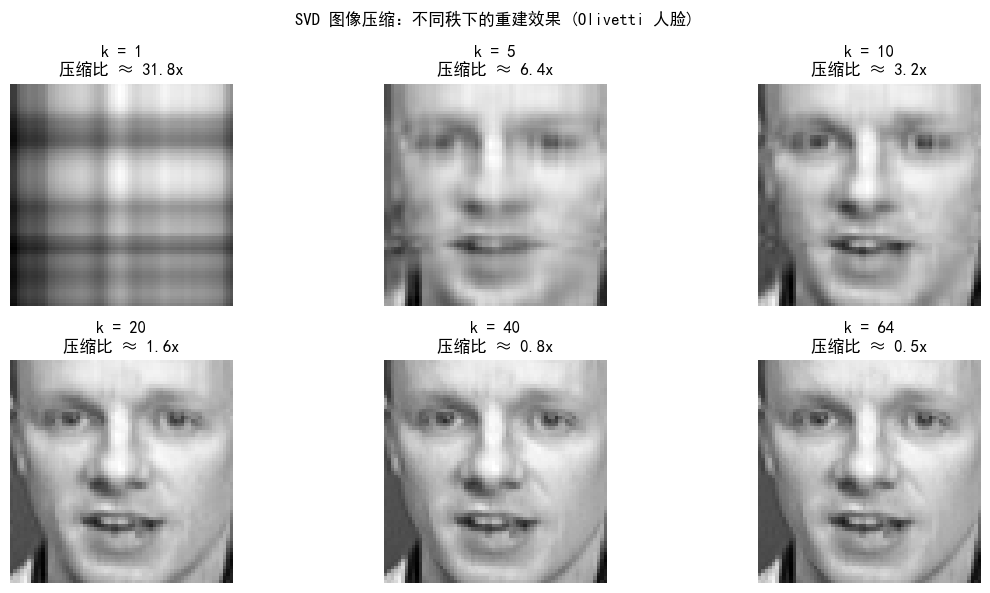

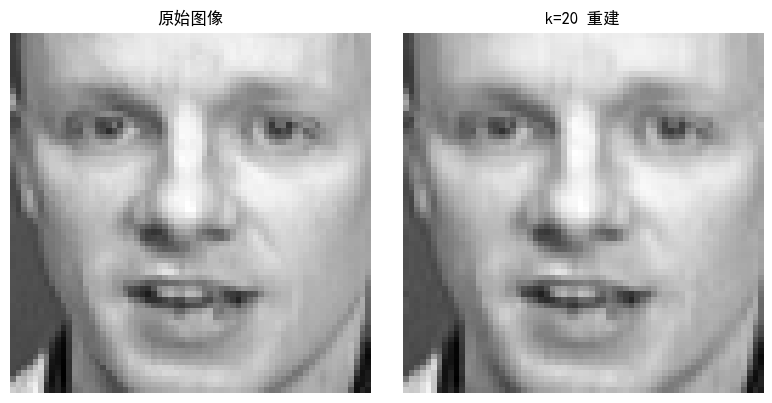

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


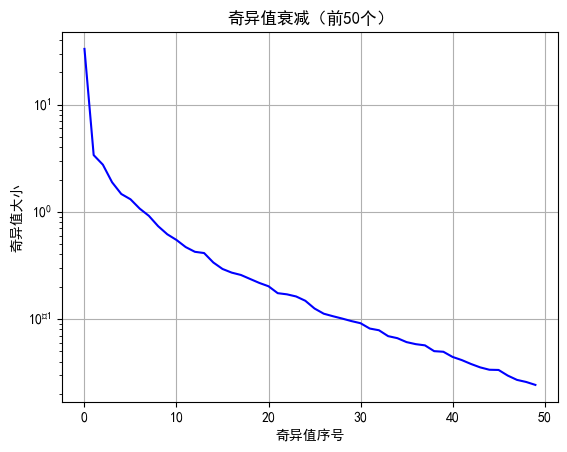

In [ ]:
"""
任务三：理解 SVD 的基本原理，编程实现其在视觉、语言等 AI 任务中的应用

使用 Olivetti 人脸数据进行图像压缩，使用模拟文本数据进行潜在语义分析（LSA）。
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# ------------------------------
# 图像压缩（使用 Olivetti 人脸数据）
# ------------------------------
print("=== 图像压缩：SVD 低秩近似（Olivetti 人脸） ===")
faces = fetch_olivetti_faces(shuffle=True, random_state=42)

img = faces.images[0]  

# 对图像进行 SVD
U, S, Vt = np.linalg.svd(img, full_matrices=False)

# 不同 k 值下重建图像并计算压缩比
k_values = [1, 5, 10, 20, 40, 64]  # 从极小到全秩
plt.figure(figsize=(12, 6))

for idx, k in enumerate(k_values):
    # 重建图像：取前 k 个奇异值
    img_recon = U[:, :k] @ np.diag(S[:k]) @ Vt[:k, :]
    # 计算压缩比：原始数据量 m*n，压缩后数据量 k*(m+n+1)（U, Vt, S）
    original_size = img.size
    compressed_size = k * (img.shape[0] + img.shape[1] + 1)
    ratio = original_size / compressed_size

    plt.subplot(2, 3, idx+1)
    plt.imshow(img_recon, cmap='gray')
    plt.title(f'k = {k}\n压缩比 ≈ {ratio:.1f}x')
    plt.axis('off')

plt.suptitle('SVD 图像压缩：不同秩下的重建效果 (Olivetti 人脸)')
plt.tight_layout()
plt.show()

# 展示原始图像和低秩近似误差
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('原始图像')
plt.axis('off')

plt.subplot(1, 2, 2)
# 用 k=20 重建
img_k20 = U[:, :20] @ np.diag(S[:20]) @ Vt[:20, :]
plt.imshow(img_k20, cmap='gray')
plt.title('k=20 重建')
plt.axis('off')
plt.tight_layout()
plt.show()

# 奇异值衰减曲线
plt.figure()
plt.semilogy(S[:50], 'b-')
plt.title('奇异值衰减（前50个）')
plt.xlabel('奇异值序号')
plt.ylabel('奇异值大小')
plt.grid(True)
plt.show()



使用设备: cpu
Files already downloaded and verified
Files already downloaded and verified

===== 训练 基线 CNN =====
Baseline 2/12 | Acc 62.14%
Baseline 4/12 | Acc 65.46%
Baseline 6/12 | Acc 69.27%
Baseline 8/12 | Acc 68.90%
Baseline 10/12 | Acc 68.44%
Baseline 12/12 | Acc 69.01%

===== 训练 SVDNet =====

=== 阶段 0：初始训练 ===
Epoch  1 | Loss 1.676 | Acc 49.21% | Ortho 0.0049
Epoch  2 | Loss 1.321 | Acc 54.99% | Ortho 0.0049
Epoch  3 | Loss 1.194 | Acc 57.03% | Ortho 0.0049
Epoch  4 | Loss 1.117 | Acc 59.59% | Ortho 0.0049

SVD 正交化完成 → 正交性: 0.0050

=== 约束阶段 ===
Epoch  1 | Acc 62.08% | Ortho 0.0050
Epoch  2 | Acc 62.99% | Ortho 0.0050
Epoch  3 | Acc 62.98% | Ortho 0.0050
Epoch  4 | Acc 63.72% | Ortho 0.0050

=== 放松阶段 ===
Epoch  1 | Acc 62.31% | Ortho 0.0050
Epoch  2 | Acc 64.07% | Ortho 0.0050
Epoch  3 | Acc 62.94% | Ortho 0.0049
Epoch  4 | Acc 65.68% | Ortho 0.0049


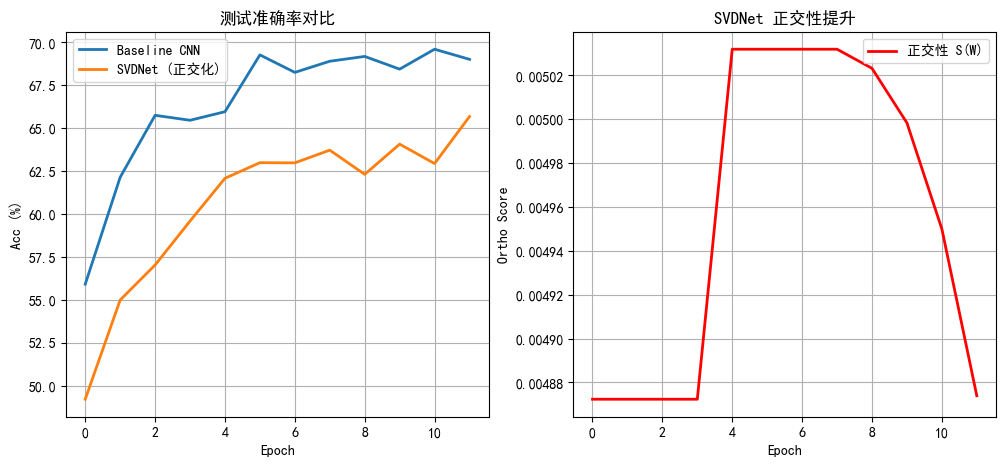


==================== 最终结果 ====================
基线 CNN 准确率: 69.01%
SVDNet   准确率: 65.68%


In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt

# 轻薄本专用：强制 CPU，稳定不卡
device = torch.device("cpu")
print(f"使用设备: {device}")
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False


# ======================== 平衡版超参数 ========================
BATCH_SIZE = 64
EIGEN_DIM = 256        # 加大特征维度 → SVDNet 优势明显
NUM_RRI = 1            # 保持 1 轮 RRI，速度快
EPOCHS_PER_STAGE = 4   # 每阶段 4 轮，稳定收敛
LEARNING_RATE = 1e-3
USE_DATA_RATIO = 0.4   # 使用 40% 数据，比之前更准但不慢
# ==============================================================

torch.manual_seed(42)
np.random.seed(42)

# ------------------------------
# 数据预处理
# ------------------------------
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_set = datasets.CIFAR10('./data', train=True, download=True, transform=transform)
test_set = datasets.CIFAR10('./data', train=False, download=True, transform=transform)

# 取部分数据加速
train_size = int(USE_DATA_RATIO * len(train_set))
test_size = len(test_set)
train_subset = torch.utils.data.Subset(train_set, range(train_size))
test_subset = torch.utils.data.Subset(test_set, range(test_size))

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = DataLoader(test_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# ------------------------------
# 加大容量的网络结构
# ------------------------------
class BaselineCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool = nn.AvgPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 8 * 8, EIGEN_DIM)
        self.fc2 = nn.Linear(EIGEN_DIM, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = x.view(-1, 64 * 8 * 8)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

class SVDNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool = nn.AvgPool2d(2, 2)
        self.eigen = nn.Linear(64 * 8 * 8, EIGEN_DIM, bias=False)
        self.fc = nn.Linear(EIGEN_DIM, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = x.view(-1, 64 * 8 * 8)
        x = self.eigen(x)
        x = self.fc(x)
        return x

    def get_eigen_weight(self):
        return self.eigen.weight.data

    def set_eigen_weight(self, W):
        self.eigen.weight.data = W

# ------------------------------
# 训练工具函数
# ------------------------------
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    correct = 0
    for data, target in loader:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        pred = output.argmax(dim=1, keepdim=True)
        correct += pred.eq(target.view_as(pred)).sum().item()
    return total_loss / len(loader), 100. * correct / len(loader.dataset)

def evaluate(model, loader):
    model.eval()
    correct = 0
    with torch.no_grad():
        for data, target in loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()
    return 100. * correct / len(loader.dataset)

def compute_orthogonality_metric(W):
    if W.shape[0] >= W.shape[1]:
        G = W @ W.T
    else:
        G = W.T @ W
    trace = torch.diag(G).sum().item()
    abs_sum = torch.abs(G).sum().item()
    return trace / abs_sum if abs_sum != 0 else 1.0

# ------------------------------
# 修复版 RRI 训练
# ------------------------------
def train_svdnet(model):
    params_no_eigen = [p for n, p in model.named_parameters() if 'eigen' not in n]
    optimizer = optim.Adam(params_no_eigen, lr=LEARNING_RATE, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()
    acc_history = []
    ortho_history = []

    print("\n=== 阶段 0：初始训练 ===")
    for epoch in range(EPOCHS_PER_STAGE):
        loss, acc = train_one_epoch(model, train_loader, optimizer, criterion)
        test_acc = evaluate(model, test_loader)
        acc_history.append(test_acc)
        W = model.get_eigen_weight()
        ortho = compute_orthogonality_metric(W)
        ortho_history.append(ortho)
        print(f"Epoch {epoch+1:2d} | Loss {loss:.3f} | Acc {test_acc:.2f}% | Ortho {ortho:.4f}")

    # === 核心：SVD 正交化（已修复）===
    W = model.get_eigen_weight()
    U, S, Vt = torch.linalg.svd(W, full_matrices=False)
    W_ortho = U @ Vt
    model.set_eigen_weight(W_ortho)
    print(f"\nSVD 正交化完成 → 正交性: {compute_orthogonality_metric(W_ortho):.4f}")

    # 约束阶段
    print("\n=== 约束阶段 ===")
    optimizer = optim.Adam(params_no_eigen, lr=LEARNING_RATE*0.5)
    for epoch in range(EPOCHS_PER_STAGE):
        loss, acc = train_one_epoch(model, train_loader, optimizer, criterion)
        test_acc = evaluate(model, test_loader)
        acc_history.append(test_acc)
        ortho = compute_orthogonality_metric(model.get_eigen_weight())
        ortho_history.append(ortho)
        print(f"Epoch {epoch+1:2d} | Acc {test_acc:.2f}% | Ortho {ortho:.4f}")

    # 放松阶段
    print("\n=== 放松阶段 ===")
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE*0.2)
    for epoch in range(EPOCHS_PER_STAGE):
        loss, acc = train_one_epoch(model, train_loader, optimizer, criterion)
        test_acc = evaluate(model, test_loader)
        acc_history.append(test_acc)
        ortho = compute_orthogonality_metric(model.get_eigen_weight())
        ortho_history.append(ortho)
        print(f"Epoch {epoch+1:2d} | Acc {test_acc:.2f}% | Ortho {ortho:.4f}")

    return acc_history, ortho_history

# ------------------------------
# 主程序
# ------------------------------
def main():
    print("\n===== 训练 基线 CNN =====")
    baseline = BaselineCNN().to(device)
    opt_b = optim.Adam(baseline.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
    baseline_acc = []
    total_epochs = EPOCHS_PER_STAGE * 3

    for epoch in range(total_epochs):
        loss, _ = train_one_epoch(baseline, train_loader, opt_b, nn.CrossEntropyLoss())
        acc = evaluate(baseline, test_loader)
        baseline_acc.append(acc)
        if (epoch+1) % 2 == 0:
            print(f"Baseline {epoch+1}/{total_epochs} | Acc {acc:.2f}%")

    print("\n===== 训练 SVDNet =====")
    svdnet = SVDNet().to(device)
    svd_acc, svd_ortho = train_svdnet(svdnet)

    # 绘图
    plt.figure(figsize=(12,5))
    plt.subplot(121)
    plt.plot(baseline_acc, label='Baseline CNN', linewidth=2)
    plt.plot(svd_acc, label='SVDNet (正交化)', linewidth=2)
    plt.title('测试准确率对比')
    plt.xlabel('Epoch')
    plt.ylabel('Acc (%)')
    plt.legend()
    plt.grid()

    plt.subplot(122)
    plt.plot(svd_ortho, color='r', linewidth=2, label='正交性 S(W)')
    plt.title('SVDNet 正交性提升')
    plt.xlabel('Epoch')
    plt.ylabel('Ortho Score')
    plt.legend()
    plt.grid()
    plt.show()

    print("\n==================== 最终结果 ====================")
    print(f"基线 CNN 准确率: {baseline_acc[-1]:.2f}%")
    print(f"SVDNet   准确率: {svd_acc[-1]:.2f}%")
    print("====================================================")

if __name__ == "__main__":
    main()